# Детерминированная валидация GCC-PHAT

Проверяется только чистая оценка TDOA на уже принятом генераторе. SRP-PHAT, отражения, ветер, движение и случайный шум здесь не используются.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib.pyplot as plt
from estimators.gcc_phat import gcc_phat
from model.geometry import comparison_arrays
from simulation.propagation import simulate_propagation
from simulation.signals import deterministic_bandlimited_signal
from validation.gcc_study import (
    GCC_SAMPLING_RATE_HZ, benchmark_fractional_delay_methods,
    run_gcc_phat_validation_study,
)
plt.rcParams['figure.figsize'] = (8, 4.5)

## Знак и дробная оценка

Для пары `(i,j)` используется $G_{ij}=X_iX_j^*/|X_iX_j^*|$. Поэтому положительный максимум означает $\hat\tau_{ij}=T_i-T_j>0$: канал `i` запаздывает относительно `j`. Корреляция вычисляется на сетке с 32-кратной интерполяцией, затем максимум уточняется параболой.

In [2]:
benchmark = benchmark_fractional_delay_methods(output_csv=ROOT/'results/fractional_delay_benchmark.csv')
gcc_rows = run_gcc_phat_validation_study(output_csv=ROOT/'results/gcc_phat_validation.csv')
fft_max = max(row['frequency_max_abs_error_samples'] for row in gcc_rows)
fir_max = max(row['fir_max_abs_error_samples'] for row in gcc_rows)
cross_max = max(row['generator_max_difference_samples'] for row in gcc_rows)
print(f'GCC configurations: {len(gcc_rows)}')
print(f'max errors [samples]: FFT={fft_max:.3e}, FIR={fir_max:.3e}, cross={cross_max:.3e}')

GCC configurations: 12
max errors [samples]: FFT=5.031e-07, FIR=5.868e-07, cross=1.340e-07


## Скорость fractional delay

Frequency-domain реализация остаётся независимым высокоточным эталоном. Времена являются измерением текущей машины, поэтому pytest не содержит хрупкого требования к абсолютной скорости.

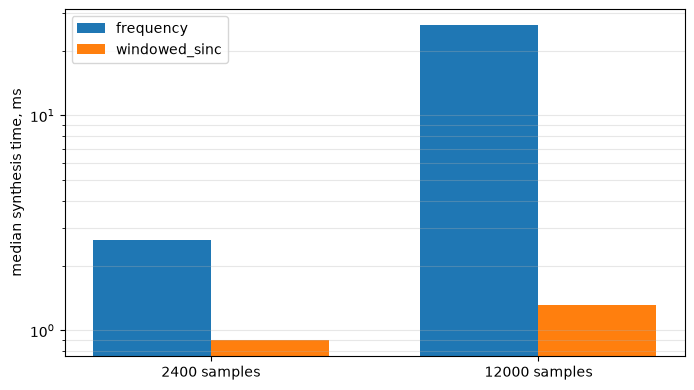

 2400 samples: frequency/FIR=2.92x
12000 samples: frequency/FIR=20.00x


In [3]:
durations = sorted({float(row['duration_s']) for row in benchmark})
x = np.arange(len(durations)); width = 0.36
fig, ax = plt.subplots()
for offset, method in [(-width/2, 'frequency'), (width/2, 'windowed_sinc')]:
    values = [1000*next(float(r['median_time_s']) for r in benchmark if r['duration_s']==d and r['method']==method) for d in durations]
    ax.bar(x+offset, values, width, label=method)
ax.set_xticks(x, [f'{int(d*GCC_SAMPLING_RATE_HZ)} samples' for d in durations])
ax.set_ylabel('median synthesis time, ms'); ax.set_yscale('log'); ax.grid(True, axis='y', which='both', alpha=.3); ax.legend();
plt.show()
for d in durations:
    row = next(r for r in benchmark if r['duration_s']==d)
    print(f'{int(d*GCC_SAMPLING_RATE_HZ):5d} samples: frequency/FIR={float(row["frequency_to_fir_speedup"]):.2f}x')

## Ошибка относительно истинных TDOA и согласие генераторов

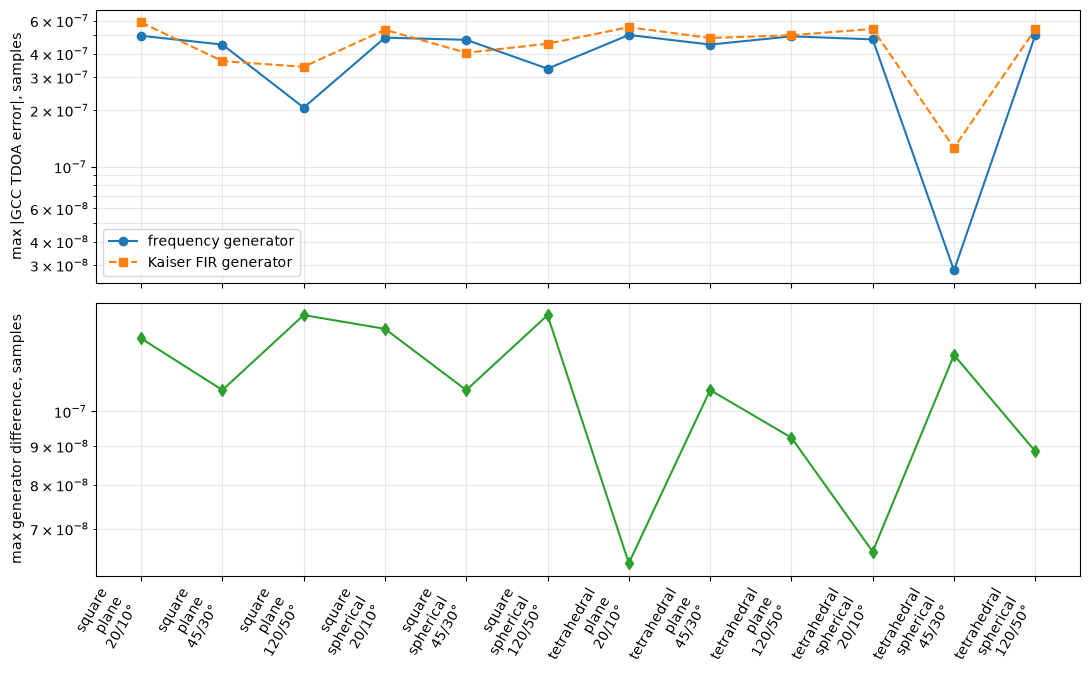

In [4]:
labels = [f"{r['geometry']}\n{r['propagation_model']}\n{int(r['azimuth_deg'])}/{int(r['elevation_deg'])}°" for r in gcc_rows]
idx = np.arange(len(gcc_rows))
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].semilogy(idx, [r['frequency_max_abs_error_samples'] for r in gcc_rows], 'o-', label='frequency generator')
axes[0].semilogy(idx, [r['fir_max_abs_error_samples'] for r in gcc_rows], 's--', label='Kaiser FIR generator')
axes[0].set_ylabel('max |GCC TDOA error|, samples'); axes[0].grid(True, which='both', alpha=.3); axes[0].legend()
axes[1].semilogy(idx, [r['generator_max_difference_samples'] for r in gcc_rows], 'd-', color='tab:green')
axes[1].set_ylabel('max generator difference, samples'); axes[1].set_xticks(idx, labels, rotation=60, ha='right'); axes[1].grid(True, which='both', alpha=.3)
plt.tight_layout(); plt.show()

## Пример корреляционного максимума и многоканальных сигналов

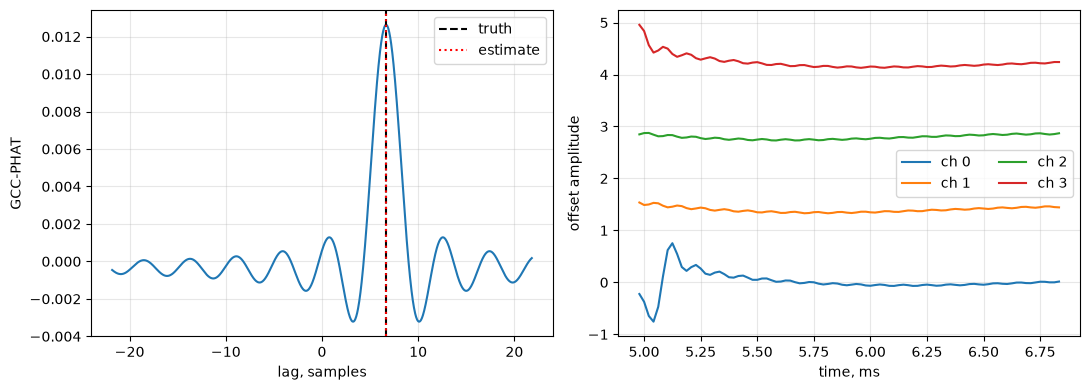

pair (0,3): truth=6.665999224, estimate=6.665998864 samples


In [5]:
fs = GCC_SAMPLING_RATE_HZ
source = deterministic_bandlimited_signal(fs, .04, minimum_frequency_hz=300, maximum_frequency_hz=10000, tone_count=31)
positions = comparison_arrays()['square']
prop = simulate_propagation(source, fs, positions, phi=np.deg2rad(20), elevation=np.deg2rad(10), distance_m=20, propagation_model='plane', delay_method='windowed_sinc')
i, j = 0, 3
estimate = gcc_phat(prop.channels[i], prop.channels[j], fs, maximum_delay_seconds=np.linalg.norm(positions[i]-positions[j])/343+2/fs, interpolation_factor=32, minimum_frequency_hz=300, maximum_frequency_hz=10000)
truth_samples = prop.tdoa_matrix_seconds[i,j]*fs
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(estimate.lags_samples, estimate.correlation); axes[0].axvline(truth_samples, color='k', ls='--', label='truth'); axes[0].axvline(estimate.delay_samples, color='r', ls=':', label='estimate'); axes[0].set_xlabel('lag, samples'); axes[0].set_ylabel('GCC-PHAT'); axes[0].legend(); axes[0].grid(True, alpha=.3)
start, stop = prop.valid_region; start += 150
fragment = slice(start, min(start+90, stop)); time_ms = 1000*np.arange(prop.channels.shape[1])[fragment]/fs
for channel in range(4): axes[1].plot(time_ms, prop.channels[channel,fragment]+1.4*channel, label=f'ch {channel}')
axes[1].set_xlabel('time, ms'); axes[1].set_ylabel('offset amplitude'); axes[1].legend(ncol=2); axes[1].grid(True, alpha=.3)
plt.tight_layout(); plt.show()
print(f'pair ({i},{j}): truth={truth_samples:.9f}, estimate={estimate.delay_samples:.9f} samples')

In [6]:
assert len(gcc_rows) == 12
assert fft_max < 2e-4 and fir_max < 2e-4 and cross_max < 2e-4
assert all(float(row['frequency_to_fir_speedup']) > 2 for row in benchmark)
print('Deterministic GCC-PHAT acceptance passed; FIR is approved for future bulk synthesis, frequency-domain remains the reference.')

Deterministic GCC-PHAT acceptance passed; FIR is approved for future bulk synthesis, frequency-domain remains the reference.
